# Introduction to Logical Constraints: Connecting Binary Decisions Through Rules

This notebook introduces **logical constraints** – rules that connect binary yes/no decisions in optimization models.

Understanding logical constraints is critical because:
- **Many real policies are IF-THEN rules**, not just simple yes/no counts
- **Binary variables alone cannot express dependencies** between decisions
- **Ignoring logical rules produces "optimal" solutions that violate policy or operations**
- **Encoding logical constraints inside the model makes every solution automatically policy-compliant**

In Lesson 7, you learned how binary variables represent independent yes/no decisions. In this Lesson 8 notebook, you will see what happens when those decisions are **connected** and how to model those connections correctly.


## Key Concepts

**Binary decisions vs logical rules**
- Binary variables represent independent yes/no choices: open vs not open, hire vs not hire.
- Logical constraints link those choices: **IF** one decision is 1, **THEN** another must be 1 (or 0).

**Logical constraints**
- IF-THEN activation: choosing A **requires** B.
- Suppression: choosing A **prevents** B.
- These rules come directly from business policies, regulations, and operating procedures.

**Why they matter**
- Without logical constraints, models recommend decisions that are cheap but **break policy**.
- With logical constraints, every solution the model returns is **operationally valid**.

**Critical insight**: Logical constraints are how we make optimization models obey real organizational rules, not just math.


## Scenario: Staffing a Night Shift Without and With Logical Constraints

You manage a small operations center with a **day shift** and a **night shift**.

**Decisions**:
- `open_day` – 1 if the day shift is open, 0 if closed (binary)
- `open_night` – 1 if the night shift is open, 0 if closed (binary)
- `assign_supervisor` – 1 if a supervisor is assigned, 0 if not (binary)

**Business policy**:
- "If the night shift is open, a supervisor **must** be assigned."

**The challenge**:
- A naïve binary model might open the night shift **without** assigning a supervisor to save cost.
- That solution is **cheapest on paper** but **invalid** operationally.

In this notebook, you will:
1. Build a simple binary model **without** the logical constraint and see the unrealistic solution it recommends.
2. Add a logical constraint that enforces the policy: **IF** `open_night = 1` **THEN** `assign_supervisor = 1`.
3. Compare the solutions side by side and interpret the impact of the logical rule.


## Step 1: Install Required Packages

### Setup: Install Required Packages

To run the optimization models in this notebook, we need to install the PuLP library.

**What this code does:** Installs the `pulp` package (for optimization) and supporting libraries used in later notebooks.

**What to look for in the output:** You should see "Requirement already satisfied" if `pulp` is already installed, or installation messages if it needs to be added.

In [1]:
# Install pulp and related libraries (required for optimization)
# This is needed in Google Colab; can be skipped if already installed locally.
%pip install pulp pandas numpy matplotlib -q



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Import Libraries

### Setup: Import Libraries

We'll use Python libraries to build our models, create small tables, and solve optimization problems.

**What this code does:** Loads the libraries we need – `pandas` (for data tables), `numpy` (for calculations), `matplotlib` (for simple visuals), and `pulp` (for optimization).

**What to look for in the output:** No output is expected here – these imports happen silently in the background. If you see an error, one of the packages may not be installed.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD

# Set a simple, readable plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## Step 3: Define Problem Data

We will use a small cost model that makes the **night shift without a supervisor** look artificially attractive unless we encode the policy.

**Assumptions for this example**:
- Day shift cost per unit time: $1,500
- Night shift cost per unit time: $1,000 (cheaper than the day shift)
- Supervisor cost per unit time: $600

**Coverage requirement**:
- At least **one** of the two shifts (day or night) must be open.

**Policy**:
- If the night shift is open, a supervisor must be assigned.

**Objective**:
- Minimize total cost while deciding whether to open the day and night shifts and whether to assign a supervisor.

Without the logical constraint, the model will satisfy coverage by opening the **cheaper night shift without a supervisor**. With the policy encoded, it will need to either:
- Open the night shift **with** a supervisor (more expensive), or
- Switch to opening the day shift instead.

We'll first set up the data in a small, readable table.

In [3]:
# Problem data
costs = {
    "open_day": 1500,           # cost of running the day shift
    "open_night": 1000,        # cost of running the night shift
    "assign_supervisor": 600   # cost of assigning a supervisor
}

policy_text = "If the night shift is open, a supervisor must be assigned."

print("PROBLEM DATA:")
print("=" * 60)
print(f"Day shift cost:           ${costs['open_day']:,}")
print(f"Night shift cost:         ${costs['open_night']:,}")
print(f"Supervisor cost:          ${costs['assign_supervisor']:,}")
print("-" * 60)
print("Coverage requirement: at least one of day or night must be open.")
print("Policy:")
print(f"  {policy_text}")

PROBLEM DATA:
Day shift cost:           $1,500
Night shift cost:         $1,000
Supervisor cost:          $600
------------------------------------------------------------
Coverage requirement: at least one of day or night must be open.
Policy:
  If the night shift is open, a supervisor must be assigned.


## Step 4: Model 1 – Binary Decisions Without the Logical Constraint

### Create the Optimization Model (No Policy Encoded)

We first build a **naïve binary model** that ignores the policy.

**What this code does:**
- Creates binary variables for `open_day`, `open_night`, and `assign_supervisor`.
- Minimizes **total cost** = day cost + night cost + supervisor cost.
- Does **not** include any constraint linking `open_night` and `assign_supervisor`.

**What to look for in the output:**
- The selected values for each variable (0 or 1).
- Whether the model recommends opening the night shift **without** a supervisor to save cost.

In [4]:
# Model 1: Binary decisions without the logical constraint

model1 = LpProblem("Shift_Staffing_Without_Logical_Constraint", LpMinimize)

# Decision variables (binary)
open_day_1 = LpVariable("open_day", lowBound=0, upBound=1, cat="Binary")
open_night_1 = LpVariable("open_night", lowBound=0, upBound=1, cat="Binary")
assign_supervisor_1 = LpVariable("assign_supervisor", lowBound=0, upBound=1, cat="Binary")

# Objective: minimize total cost
model1 += (
    costs["open_day"] * open_day_1
    + costs["open_night"] * open_night_1
    + costs["assign_supervisor"] * assign_supervisor_1,
    "Total_Cost"
)

# Coverage requirement: at least one shift must be open
model1 += open_day_1 + open_night_1 >= 1, "At_least_one_shift_open"

# Note: NO logical constraint is added here.

# Solve the model
solver = PULP_CBC_CMD(msg=False)
model1.solve(solver)

status1 = LpStatus[model1.status]
print(f"Model 1 status: {status1}")

# Collect results into a table
results1 = pd.DataFrame({
    "Decision": ["Open day shift", "Open night shift", "Assign supervisor"],
    "Variable": ["open_day", "open_night", "assign_supervisor"],
    "Value (0/1)": [
        int(open_day_1.value()),
        int(open_night_1.value()),
        int(assign_supervisor_1.value())
    ],
    "Cost if 1": [
        costs["open_day"],
        costs["open_night"],
        costs["assign_supervisor"],
    ],
})

results1["Total cost contribution"] = results1["Value (0/1)"] * results1["Cost if 1"]

print("\nMODEL 1 DECISIONS (NO LOGICAL CONSTRAINT):")
print(results1.to_string(index=False))
print(f"\nTotal cost (Model 1): ${value(model1.objective):,}")

Model 1 status: Optimal

MODEL 1 DECISIONS (NO LOGICAL CONSTRAINT):
         Decision          Variable  Value (0/1)  Cost if 1  Total cost contribution
   Open day shift          open_day            0       1500                        0
 Open night shift        open_night            1       1000                     1000
Assign supervisor assign_supervisor            0        600                        0

Total cost (Model 1): $1,000.0


### Interpreting Model 1

Look carefully at the decisions in Model 1:

- With the new cost and coverage assumptions, the cheapest way to satisfy "at least one shift open" is to open **only the night shift** and **not** assign a supervisor.
- This produces `open_night = 1` and `assign_supervisor = 0` – a **policy violation** that the model does not recognize, because we have not told it about the rule.

This is exactly what happens when we rely on binary decisions alone without encoding the logical rule. The optimizer does not know the policy unless we tell it.

## Step 5: Model 2 – Adding the IF-THEN Logical Constraint

Now we encode the policy:

> If the night shift is open, a supervisor must be assigned.

In binary terms, this means:
- If `open_night = 1` then `assign_supervisor = 1`.

One simple way to encode this as a linear constraint is:
- `assign_supervisor ≥ open_night`

If `open_night = 1`, the inequality forces `assign_supervisor = 1`.
If `open_night = 0`, the inequality allows `assign_supervisor` to be 0 or 1 (we will let the objective decide).

**What this code does:**
- Builds a second model with the same decisions and costs.
- Adds the logical constraint `assign_supervisor ≥ open_night`.
- Solves and reports the new decisions.

**What to look for in the output:**
- Whether any solution with `open_night = 1` also has `assign_supervisor = 1`.
- How the total cost changes once the policy is enforced inside the model.

In [5]:
# Model 2: Binary decisions WITH the logical constraint

model2 = LpProblem("Shift_Staffing_With_Logical_Constraint", LpMinimize)

# Decision variables (binary)
open_day_2 = LpVariable("open_day", lowBound=0, upBound=1, cat="Binary")
open_night_2 = LpVariable("open_night", lowBound=0, upBound=1, cat="Binary")
assign_supervisor_2 = LpVariable("assign_supervisor", lowBound=0, upBound=1, cat="Binary")

# Objective: minimize total cost
model2 += (
    costs["open_day"] * open_day_2
    + costs["open_night"] * open_night_2
    + costs["assign_supervisor"] * assign_supervisor_2,
    "Total_Cost"
)

# Coverage requirement: at least one shift must be open (same as Model 1)
model2 += open_day_2 + open_night_2 >= 1, "At_least_one_shift_open"

# Logical constraint: if night shift is open, supervisor must be assigned
# Encoded as: assign_supervisor >= open_night
model2 += assign_supervisor_2 >= open_night_2, "IF_night_open_THEN_supervisor_assigned"

# Solve the model
model2.solve(solver)

status2 = LpStatus[model2.status]
print(f"Model 2 status: {status2}")

# Collect results into a table
results2 = pd.DataFrame({
    "Decision": ["Open day shift", "Open night shift", "Assign supervisor"],
    "Variable": ["open_day", "open_night", "assign_supervisor"],
    "Value (0/1)": [
        int(open_day_2.value()),
        int(open_night_2.value()),
        int(assign_supervisor_2.value())
    ],
    "Cost if 1": [
        costs["open_day"],
        costs["open_night"],
        costs["assign_supervisor"],
    ],
})

results2["Total cost contribution"] = results2["Value (0/1)"] * results2["Cost if 1"]

print("\nMODEL 2 DECISIONS (WITH LOGICAL CONSTRAINT):")
print(results2.to_string(index=False))
print(f"\nTotal cost (Model 2): ${value(model2.objective):,}")

# Simple validation check: if open_night == 1, supervisor must be 1
if int(open_night_2.value()) == 1:
    assert int(assign_supervisor_2.value()) == 1, (
        "Logical constraint violated: night shift is open but supervisor is not assigned."
    )
    print("\nValidation check passed: whenever the night shift is open, a supervisor is assigned.")
else:
    print("\nValidation check: night shift is closed in Model 2, so the policy does not apply.")

Model 2 status: Optimal

MODEL 2 DECISIONS (WITH LOGICAL CONSTRAINT):
         Decision          Variable  Value (0/1)  Cost if 1  Total cost contribution
   Open day shift          open_day            1       1500                     1500
 Open night shift        open_night            0       1000                        0
Assign supervisor assign_supervisor            0        600                        0

Total cost (Model 2): $1,500.0

Validation check: night shift is closed in Model 2, so the policy does not apply.


## Step 6: Comparing the Two Models

To make the impact of the logical constraint clear, we can combine the two sets of decisions in a single table.

**What this code does:**
- Builds a comparison table for Model 1 (no logical constraint) and Model 2 (with logical constraint).
- Highlights how the logical rule changes the recommendation and the total cost.

**What to look for in the output:**
- Whether any policy-violating combination (`open_night = 1`, `assign_supervisor = 0`) appears in Model 1 but **not** in Model 2.
- How total cost changes once the policy is enforced.


In [6]:
# Combine Model 1 and Model 2 results for comparison

comparison = results1.merge(
    results2[["Variable", "Value (0/1)"]],
    on="Variable",
    suffixes=(" (Model 1)", " (Model 2)")
)

print("COMPARISON OF DECISIONS (MODEL 1 VS MODEL 2):")
print(comparison.to_string(index=False))

print("\nTotal cost (Model 1, no logical constraint): ${:,}".format(int(value(model1.objective))))
print("Total cost (Model 2, with logical constraint): ${:,}".format(int(value(model2.objective))))

# Quick text summary
if int(open_night_1.value()) == 1 and int(assign_supervisor_1.value()) == 0:
    print("\nModel 1 recommends opening the night shift WITHOUT a supervisor (policy violation).")
if int(open_night_2.value()) == 1 and int(assign_supervisor_2.value()) == 1:
    print("Model 2 enforces the policy: whenever the night shift is open, a supervisor is assigned.")

COMPARISON OF DECISIONS (MODEL 1 VS MODEL 2):
         Decision          Variable  Value (0/1) (Model 1)  Cost if 1  Total cost contribution  Value (0/1) (Model 2)
   Open day shift          open_day                      0       1500                        0                      1
 Open night shift        open_night                      1       1000                     1000                      0
Assign supervisor assign_supervisor                      0        600                        0                      0

Total cost (Model 1, no logical constraint): $1,000
Total cost (Model 2, with logical constraint): $1,500

Model 1 recommends opening the night shift WITHOUT a supervisor (policy violation).


## Step 7: Simple Visual – Cost Impact of Enforcing the Policy

A small bar chart can help students **see** the cost impact of enforcing the logical constraint.

**What this code does:**
- Plots total cost from Model 1 and Model 2 side by side.
- Uses a simple, large-font, single-figure layout designed to be readable in both Jupyter and Colab.

**What to look for in the output:**
- Whether enforcing the policy increases cost.
- A clean, legible chart with no overlapping labels or tiny text.

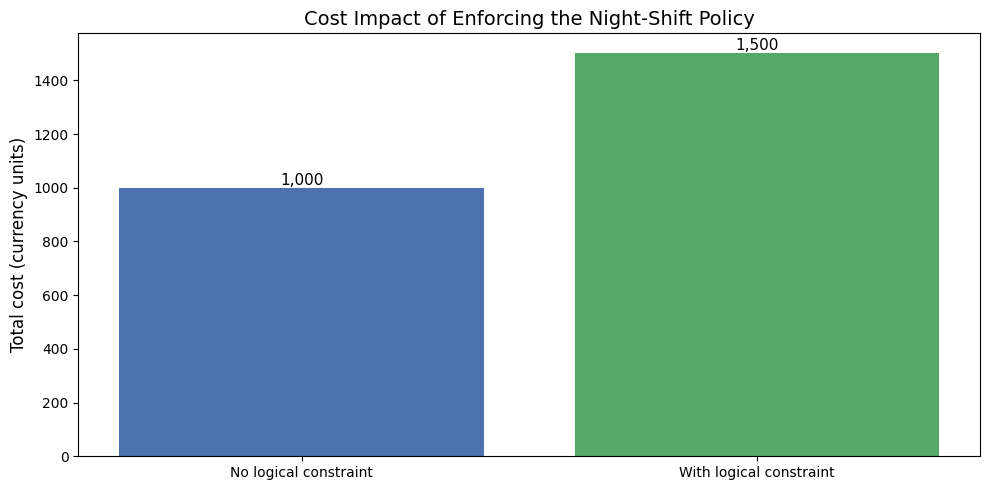

In [7]:
# Simple bar chart comparing total costs

model_names = ["No logical constraint", "With logical constraint"]
model_costs = [
    float(value(model1.objective)),
    float(value(model2.objective)),
]

fig, ax = plt.subplots()

bars = ax.bar(model_names, model_costs, color=["#4C72B0", "#55A868"])
ax.set_title("Cost Impact of Enforcing the Night-Shift Policy")
ax.set_ylabel("Total cost (currency units)")

# Add labels on top of bars
for bar, cost in zip(bars, model_costs):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(cost):,}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.tight_layout()
plt.show()

## Conclusion: Why Logical Constraints Belong Inside the Model

In this notebook, you saw that:

- **Binary variables alone are not enough** – they represent independent decisions but say nothing about how decisions depend on each other.
- A model that ignores the policy "If the night shift is open, a supervisor must be assigned" can return a solution that looks cheap but is **operationally invalid**.
- Adding a **simple logical constraint** (`assign_supervisor ≥ open_night`) forces the model to obey the policy in every solution.
- Enforcing the policy changes the solution and often increases cost – but those costs are the real costs of being compliant.

This is the core idea of Lesson 8: **logical constraints are how real-world rules enter the optimization model**. In the next notebooks, you will see how to use **indicator variables** and other patterns to handle more complex IF-THEN, either-or, and complementary policies.